<a href="https://colab.research.google.com/github/demsaid400-cpu/DI-BOOTCAMP/blob/main/Week5/Day3/Exercices_XP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [ ]:
HEIGHT = 48
WIDTH = 48
BATCH_SIZE = 32

In [ ]:
import pathlib
import os

# Download and extract the dataset
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
extracted_path = tf.keras.utils.get_file('flower_photos', origin=dataset_url, untar=True)
data_dir = pathlib.Path(extracted_path)

# Fix: The archive extracts into a 'flower_photos' directory which contains another 'flower_photos' directory
# We need to point to the one that actually contains the class subfolders.
if (data_dir / 'flower_photos').exists():
    data_dir = data_dir / 'flower_photos'

train_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(HEIGHT, WIDTH),
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(HEIGHT, WIDTH),
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

class_names = train_dataset.class_names
print(f"Detected classes: {class_names}")

Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.
Detected classes: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


In [ ]:
class_names = train_dataset.class_names

print("Nombre de classes :", len(class_names))
print(class_names)

Nombre de classes : 5
['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


In [ ]:
for class_name in class_names:
    # Use data_dir which contains the actual downloaded folders
    path = os.path.join(data_dir, class_name)
    print(class_name, ":", len(os.listdir(path)))

daisy : 633
dandelion : 898
roses : 641
sunflowers : 699
tulips : 799


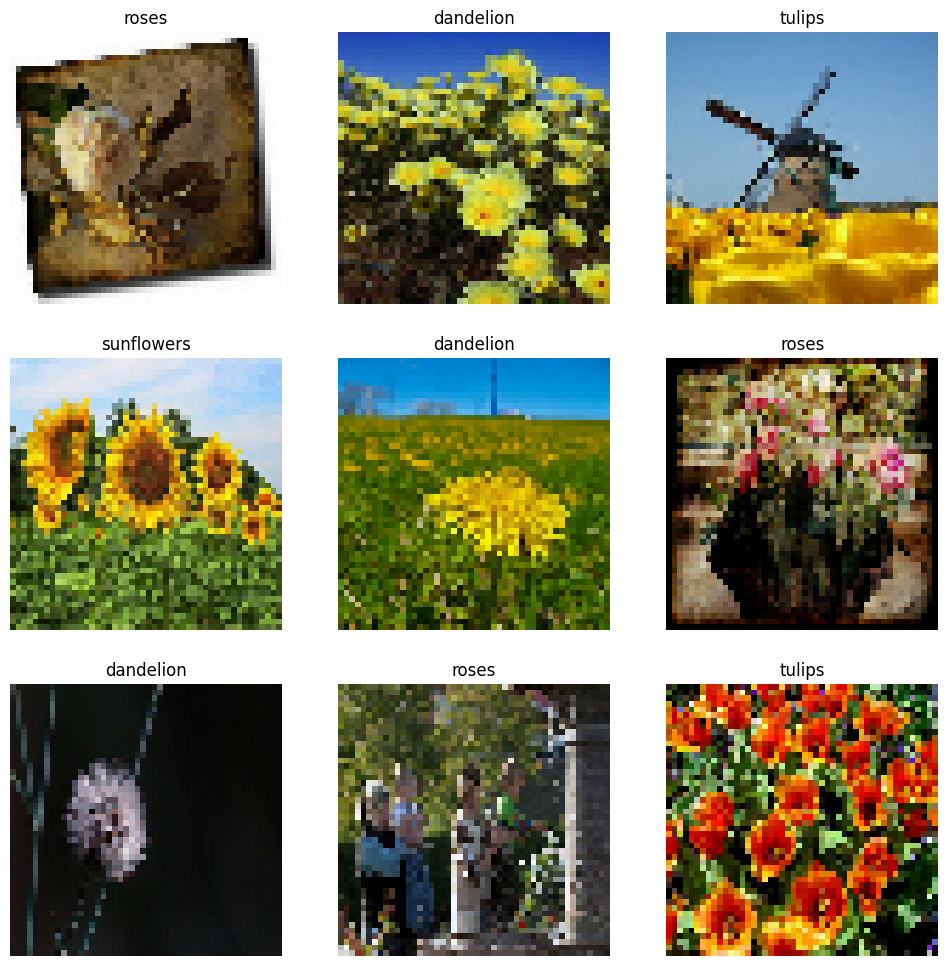

In [ ]:
def visualize_images(dataset, class_names):

    plt.figure(figsize=(12,12))

    for images, labels in dataset.take(1):

        for i in range(9):

            plt.subplot(3,3,i+1)

            plt.imshow(images[i].numpy().astype("uint8"))

            label = np.argmax(labels[i])

            plt.title(class_names[label])

            plt.axis("off")

    plt.show()


visualize_images(train_dataset, class_names)

Analyse des défis du dataset

Difficultés possibles :

Certaines fleurs ont des couleurs similaires (ex : Rose, Tulip, Carnation).
Les formes des pétales peuvent se ressembler.
Variations de luminosité et d'arrière-plan.
Différentes orientations des fleurs.
Différences de taille et de distance de prise de vue.

Ces problèmes justifient l'utilisation d'un CNN et de la data augmentation.

In [ ]:
normalization = tf.keras.layers.Rescaling(1./255)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

model = Sequential([
    Input(shape=(HEIGHT, WIDTH, 3)),
    normalization,
    Conv2D(32, (3,3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(256, activation="relu"),
    Dropout(0.5),
    Dense(len(class_names), activation="softmax")
])

### Pourquoi cette architecture ?
* **Conv2D** : détecte les motifs (bords, textures, pétales).
* **32 → 64 → 128 filtres** : apprend progressivement des caract	ristiques plus complexes.
* **MaxPooling** : r	duit la taille des cartes de caract	ristiques et limite le surapprentissage.
* **BatchNormalization** : stabilise et acc	lre l'entra	nement.
* **Dropout 0.5** : d	sactive al	atoirement des neurones pour am	liorer la g	n	ralisation.
* **Softmax** : produit une probabilit	 pour chacune des 5 classes (daisy, dandelion, roses, sunflowers, tulips).

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip(
        "horizontal"
    ),
    tf.keras.layers.RandomRotation(
        0.2
    ),
    tf.keras.layers.RandomZoom(
        0.2
    ),
    tf.keras.layers.RandomTranslation(
        0.1,
        0.1
    )
])

In [ ]:
model.layers.insert(0, data_augmentation)

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=30,
    callbacks=[early_stop]
)

Epoch 1/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 110ms/step - accuracy: 0.4843 - loss: 1.5713 - val_accuracy: 0.2398 - val_loss: 4.3231
Epoch 2/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.6008 - loss: 1.0397 - val_accuracy: 0.2398 - val_loss: 7.1116
Epoch 3/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.6611 - loss: 0.9229 - val_accuracy: 0.2398 - val_loss: 5.0353
Epoch 4/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.6873 - loss: 0.8118 - val_accuracy: 0.2807 - val_loss: 3.0599
Epoch 5/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - accuracy: 0.7313 - loss: 0.7039 - val_accuracy: 0.4550 - val_loss: 1.7495
Epoch 6/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - accuracy: 0.7497 - loss: 0.6491 - val_accuracy: 0.6035 - val_loss: 1.1655
Epoch 7/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.7933 - loss: 0.5459 - val_accuracy: 0.6104 - val_loss: 1.3318
Epoch 8/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.8266 - loss: 0.4826 - val_accuracy: 0.6608 -

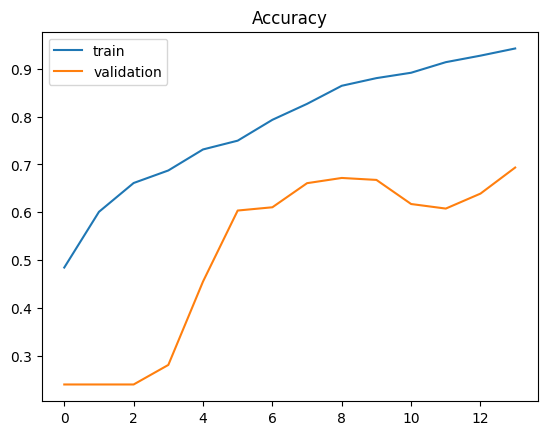

In [ ]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("Accuracy")
plt.legend([
    "train",
    "validation"
])

plt.show()

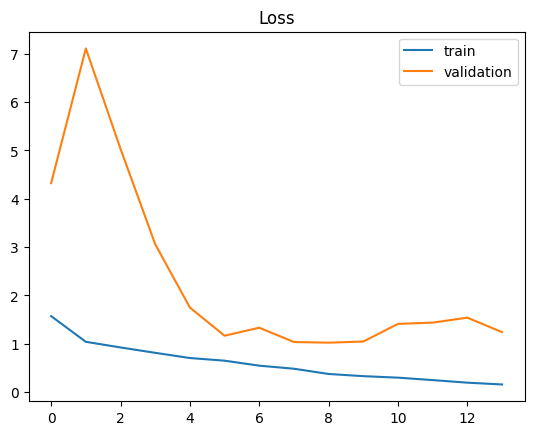

In [ ]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("Loss")
plt.legend([
    "train",
    "validation"
])

plt.show()

In [ ]:
y_pred = model.predict(val_dataset)
y_pred_classes = np.argmax(y_pred, axis=1)

23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step


In [ ]:
model.save("flower_classifier.keras")

### Part 5: Extended Performance Evaluation
Calcul de la matrice de confusion et du rapport de classification.

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step
Rapport de Classification :
              precision    recall  f1-score   support

       daisy       0.21      0.28      0.24       129
   dandelion       0.22      0.14      0.17       176
       roses       0.19      0.34      0.25       120
  sunflowers       0.16      0.12      0.14       152
      tulips       0.23      0.18      0.20       157

    accuracy                           0.20       734
   macro avg       0.20      0.21      0.20       734
weighted avg       0.20      0.20      0.20       734



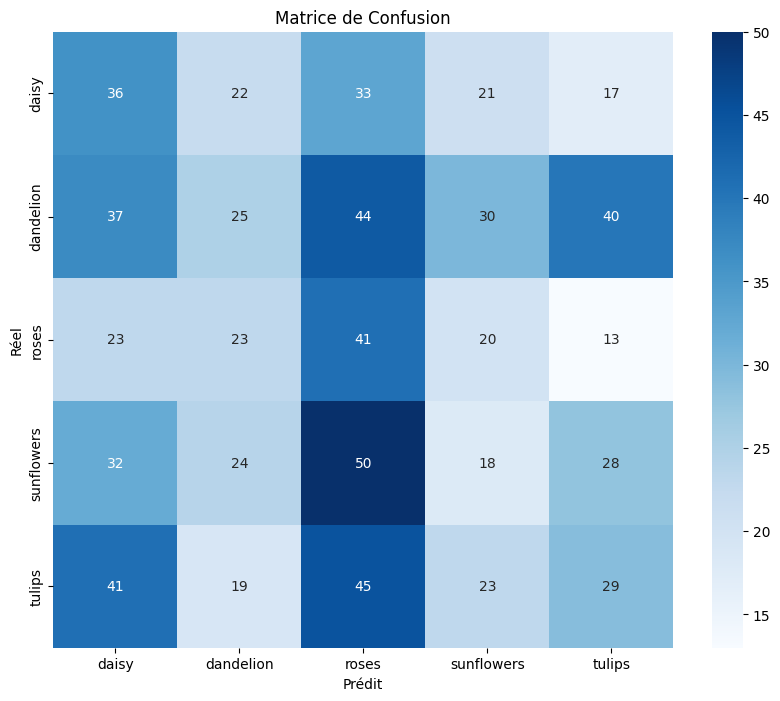

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# Récupérer les vraies étiquettes du dataset de validation
y_true = []
for images, labels in val_dataset:
    y_true.extend(np.argmax(labels.numpy(), axis=1))
y_true = np.array(y_true)

# Prédictions sur le dataset de validation
# Note: model.predict peut donner des résultats décalés si le dataset n'est pas inspecté dans l'ordre
# On recalcule les prédictions proprement
y_pred_probs = model.predict(val_dataset)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# Affichage du rapport
print("Rapport de Classification :")
print(classification_report(y_true, y_pred_classes, target_names=class_names))

# Matrice de confusion
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.title('Matrice de Confusion')
plt.show()

### Visualisation des erreurs
Identification des images mal classées pour comprendre les limites du modèle.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 840ms/step


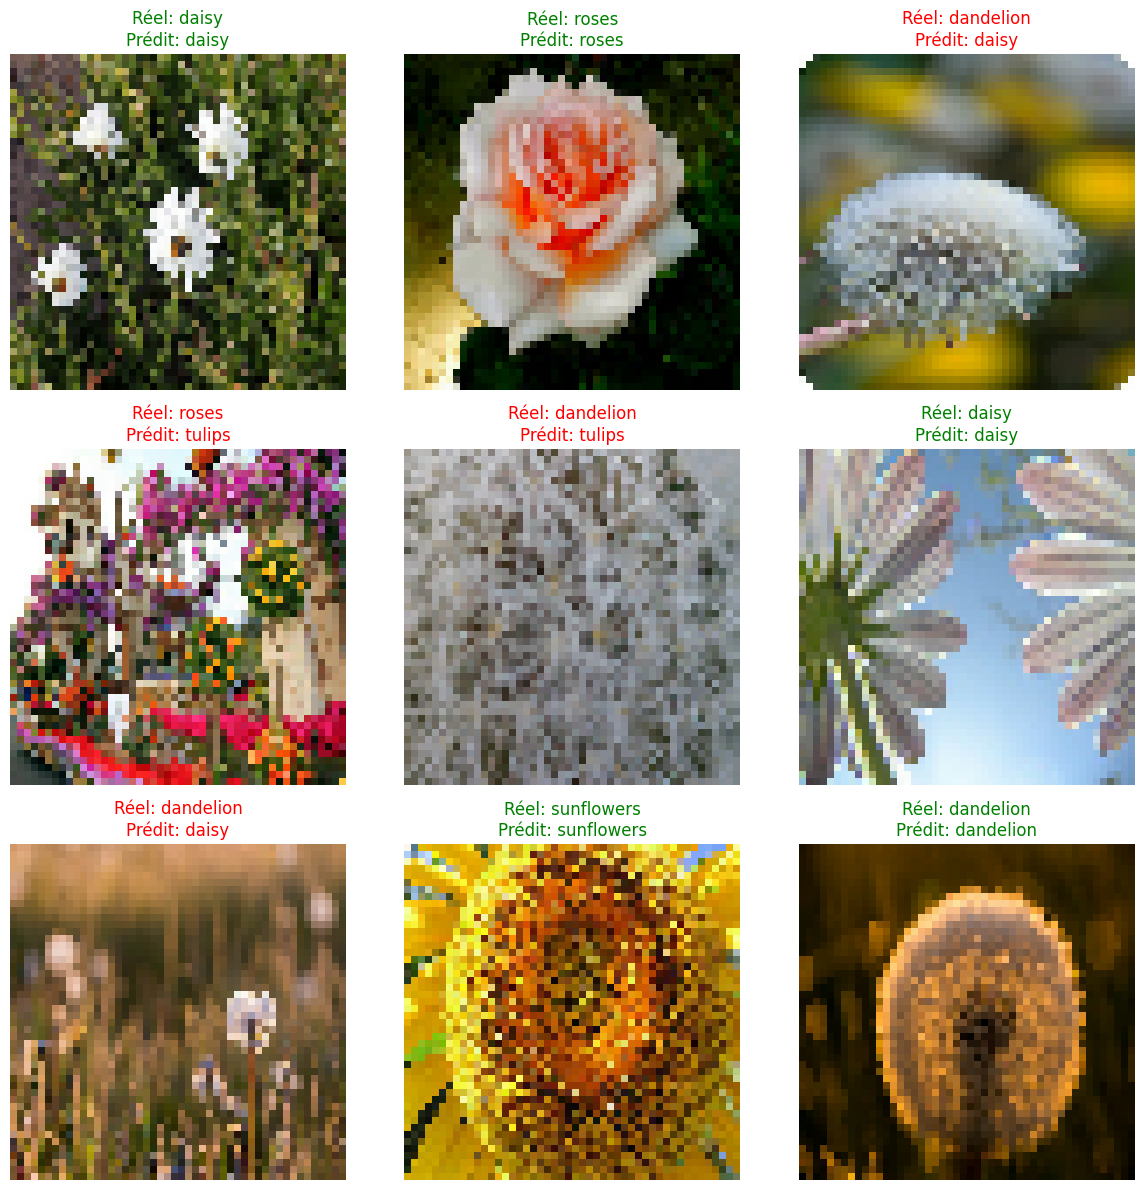

In [ ]:
plt.figure(figsize=(12, 12))

# Prendre un lot d'images de validation
for images, labels in val_dataset.take(1):
    preds = model.predict(images)
    pred_labels = np.argmax(preds, axis=1)
    true_labels = np.argmax(labels.numpy(), axis=1)

    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))

        color = "green" if pred_labels[i] == true_labels[i] else "red"

        plt.title(f"Réel: {class_names[true_labels[i]]}\nPrédit: {class_names[pred_labels[i]]}", color=color)
        plt.axis("off")

plt.tight_layout()
plt.show()